# Tech Indicator Trackers:

The following code tracks a series of technical indicators and produces an overall score that tracks if the market is bullish/bearish/neutral

### Importing packages:

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np

import matplotlib.pyplot as plt
import mplfinance as mpf

import datetime as dt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.signal import argrelextrema
import ta

import time

from __future__ import annotations

import math
from dataclasses import dataclass
from functools import reduce
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd

from dataclasses import dataclass, asdict

import itertools, pandas as pd

from datetime import timedelta
import os

import re


import warnings
warnings.filterwarnings("ignore")          

##  Tech Indicators:

In [2]:
def td_sequential(df, plot ='Yes'):
    """
    Calcola l'indicatore TD Sequential (Setup e Countdown) su un DataFrame con colonne 'High', 'Low', 'Close'.
    
      - TD Setup:
          * Bullish Setup: se il Close corrente è > Close di 4 barre fa.
          * Bearish Setup: se il Close corrente è < Close di 4 barre fa.
          * Il conteggio è consecutivo: se la condizione non si verifica, il conteggio viene resettato.
      - Al raggiungimento del conteggio 9 si attiva il Countdown:
          * Se il setup era bullish (possibile fondo), si attiva il BUY COUNTDOWN:
                – Condizione: Close corrente <= Low di 2 barre fa.
                – Il conteggio incrementa solo se, per evitare duplicati, il Close corrente è inferiore a 
                quello dell'ultimo bar che ha contato.
          * Se il setup era bearish (possibile top), si attiva il SELL COUNTDOWN:
                – Condizione: Close corrente >= High di 2 barre fa.
                – Il conteggio incrementa solo se il Close corrente è superiore a quello dell'ultimo 
                bar che ha contato.
      - Se compare una barra con la condizione opposta a quella in corso (setup o countdown), si resetta lo stato.
      
    Restituisce il DataFrame con le seguenti colonne aggiuntive:
       - 'TD_Setup_Type': 'bullish', 'bearish' o None
       - 'TD_Setup_Count': conteggio corrente del setup (0-9)
       - 'TD_Countdown_Type': 'buy', 'sell' o None (attivato dopo il completamento del setup)
       - 'TD_Countdown_Count': conteggio corrente del countdown (fino a 13)
       - 'TD_Countdown_Signal': True se il countdown ha raggiunto 13 (segnale potenzialmente rilevante)
    """
    
    df = df.copy()
    
    # Inizializzazione delle colonne
    df['TD_Setup_Type'] = None
    df['TD_Setup_Count'] = 0
    df['TD_Countdown_Type'] = None
    df['TD_Countdown_Count'] = 0
    df['TD_Countdown_Signal'] = False
    
    # Variabili di stato
    active_setup = None
    setup_count = 0
    active_countdown = None
    countdown_count = 0
    last_buy_count_close = None
    last_sell_count_close = None
    
    for i in range(len(df)):
        # --- TD SETUP ---
        if i >= 4:
            bullish_condition = df['Close'].iloc[i] > df['Close'].iloc[i-4]
            bearish_condition = df['Close'].iloc[i] < df['Close'].iloc[i-4]
            
            if active_setup is not None:
                if active_setup == 'bullish' and bearish_condition:
                    active_setup = None
                    setup_count = 0
                    active_countdown = None
                    countdown_count = 0
                    last_buy_count_close = None
                elif active_setup == 'bearish' and bullish_condition:
                    active_setup = None
                    setup_count = 0
                    active_countdown = None
                    countdown_count = 0
                    last_sell_count_close = None
            
            if active_setup is None:
                if bullish_condition:
                    active_setup = 'bullish'
                    setup_count = 1
                elif bearish_condition:
                    active_setup = 'bearish'
                    setup_count = 1
            else:
                if active_setup == 'bullish' and bullish_condition:
                    setup_count += 1
                elif active_setup == 'bearish' and bearish_condition:
                    setup_count += 1
                else:
                    active_setup = None
                    setup_count = 0
                    active_countdown = None
                    countdown_count = 0
                    last_buy_count_close = None
                    last_sell_count_close = None
        
        df.at[df.index[i], 'TD_Setup_Type'] = active_setup
        df.at[df.index[i], 'TD_Setup_Count'] = setup_count
        
        # --- Attivazione del Countdown ---
        if setup_count == 9 and active_countdown is None:
            if active_setup == 'bullish':
                active_countdown = 'buy'
                countdown_count = 0
                last_buy_count_close = None
            elif active_setup == 'bearish':
                active_countdown = 'sell'
                countdown_count = 0
                last_sell_count_close = None
        
        # --- TD COUNTDOWN ---
        if active_countdown is not None and i >= 2:
            if active_countdown == 'buy':
                if df['Close'].iloc[i] <= df['Low'].iloc[i-2]:
                    if countdown_count == 0 or (last_buy_count_close is not None and df['Close'].iloc[i] < last_buy_count_close):
                        countdown_count += 1
                        last_buy_count_close = df['Close'].iloc[i]
            elif active_countdown == 'sell':
                if df['Close'].iloc[i] >= df['High'].iloc[i-2]:
                    if countdown_count == 0 or (last_sell_count_close is not None and df['Close'].iloc[i] > last_sell_count_close):
                        countdown_count += 1
                        last_sell_count_close = df['Close'].iloc[i]
            
            df.at[df.index[i], 'TD_Countdown_Type'] = active_countdown
            df.at[df.index[i], 'TD_Countdown_Count'] = countdown_count
            
            if countdown_count >= 13:
                df.at[df.index[i], 'TD_Countdown_Signal'] = True
    
    if plot == 'Yes':
        fig = go.Figure()
    
        # Add the Close price line.
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df['Close'],
            mode='lines',
            name='Close Price',
            line=dict(color='blue')
        ))

        # Setup count markers (9)
        setup9 = df[df['TD_Setup_Count'] == 9]

        # Split by trend type:
        setup9_bearish = setup9[setup9['TD_Setup_Type'] == 'bearish']
        setup9_bullish = setup9[setup9['TD_Setup_Type'] == 'bullish']

        if not setup9_bearish.empty:
            fig.add_trace(go.Scatter(
                x=setup9_bearish.index,
                y=setup9_bearish['Close'],
                mode='markers+text',
                name='Bear Trend exhaustion',
                marker=dict(color='red', size=10, symbol='circle-open'),
                text=["9"] * len(setup9_bearish),
                textposition='top center'
            ))
        if not setup9_bullish.empty:
            fig.add_trace(go.Scatter(
                x=setup9_bullish.index,
                y=setup9_bullish['Close'],
                mode='markers+text',
                name='Bull Trend exhaustion',
                marker=dict(color='green', size=10, symbol='circle-open'),
                text=["9"] * len(setup9_bullish),
                textposition='top center'
            ))

        # Countdown count markers (13)
        countdown13 = df[df['TD_Setup_Count'] == 13]
        # Split by countdown type:
        countdown13_buy = countdown13[countdown13['TD_Countdown_Type'] == 'sell']
        countdown13_sell = countdown13[countdown13['TD_Countdown_Type'] == 'buy']

        if not countdown13_buy.empty:
            fig.add_trace(go.Scatter(
                x=countdown13_buy.index,
                y=countdown13_buy['Close'],
                mode='markers+text',
                name='Countdown 13 (Buy)',
                marker=dict(color='red', size=10, symbol='diamond'),
                text=["13"] * len(countdown13_buy),
                textposition='bottom center'
            ))
        if not countdown13_sell.empty:
            fig.add_trace(go.Scatter(
                x=countdown13_sell.index,
                y=countdown13_sell['Close'],
                mode='markers+text',
                name='Countdown 13 (Sell)',
                marker=dict(color='green', size=10, symbol='diamond'),
                text=["13"] * len(countdown13_sell),
                textposition='bottom center'
            ))

        # Update layout
        fig.update_layout(
            title={
                'text':"TD Sequential (9 and 13) ",
            'x':0.5,
            'xanchor':'center'
            },
            xaxis_title="Date",
            yaxis_title="Price",
            hovermode="x unified",
            width = 1300,
            height = 500
        )

        fig.show()
        
    return df

###########################################################################################################################################

######## -DeMark Rate Of Change Indicator---
def compute_demarker(df, period = 14, plot = 'Yes'):
    
    """
    Overbought:
    A typical threshold is DeM > 0.70. This suggests the market is extended on the upside and 
    may be at risk of a pullback or consolidation.
   
    
    Oversold:
    A typical threshold is DeM < 0.30. This suggests the market is extended on the downside 
    and may be ready to bounce.
    
    """
    
    df = df.copy()
    
    df['prev_high'] = df['High'].shift(1)
    df['prev_low'] = df['Low'].shift(1)
    
    # DeMax
    df['DeMax'] = (df['High'] - df['prev_high']).clip(lower=0)
    # Only positive differences remain; else 0
    
    # DeMin
    df['DeMin'] = (df['prev_low'] - df['Low']).clip(lower=0)
    # Only positive differences remain; else 0
    
    # Sum or rolling sum over `period`
    df['SumDeMax'] = df['DeMax'].rolling(window=period).sum()
    df['SumDeMin'] = df['DeMin'].rolling(window=period).sum()
    
    # DeMarker
    # If SumDeMax + SumDeMin == 0, we might see 0/0 => NaN, so handle that:
    df['DeM'] = df['SumDeMax'] / (df['SumDeMax'] + df['SumDeMin'])
    df['DeM'] =   df['DeM']*100
    
    if plot == 'Yes':
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03,
                    subplot_titles=("Price Candlestick", "DeMarker Indicator"),
                    row_width=[0.7, 0.7])
            
        fig.add_trace(go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'],
                                     name="Price"), row=1, col=1)
        
           # Pannello inferiore: linea dell'indicatore DeM
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df['DeM'],
            mode="lines",
            name= 'DeM'
        ), row=2, col=1)
        
        
        fig.add_hline(y=80, 
                      line=dict(color="purple", dash="dash"),
                      annotation_text="80", 
                      annotation_position="top right",
                      row=2, col=1)

        fig.add_hline(y=70, 
                      line=dict(color="red", dash="dash"),
                      annotation_text="70", 
                      annotation_position="top right",
                      row=2, col=1)

        fig.add_hline(y=30, 
                      line=dict(color="green", dash="dash"),
                      annotation_text="30", 
                      annotation_position="bottom right",
                      row=2, col=1)

        fig.add_hline(y=20, 
                      line=dict(color="blue", dash="dash"),
                      annotation_text="20", 
                      annotation_position="bottom right",
                      row=2, col=1)
        
        
        # Update layout settings
        fig.update_layout(title="Price and Demarker Indicator",
                          xaxis_title="Date",
                          yaxis_title="Price",
                          xaxis_rangeslider_visible=False,
                          template="plotly_dark")

        # Display the interactive plot
        fig.show()
    
    return df

###########################################################################################################################################
###  RSI Indicator ####

def compute_RSI(df, window = 14, plot ='Yes'):
    """
    Fornisce RSI indicator. Il dataframe deve avere una close
    column.
    """
    rsi = ta.momentum.RSIIndicator(close = df['Close'], window = window)
    df['RSI'] = rsi.rsi()
    
    if plot == "Yes":
        
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03,
                    subplot_titles=("Price Candlestick", "RSI Indicator"),
                    row_width=[0.7, 0.7])
            
        fig.add_trace(go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'],
                                     name="Price"), row=1, col=1)
        
           # Pannello inferiore: linea dell'indicatore DeM
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df['RSI'],
            mode="lines",
            name= 'RSI'
        ), row=2, col=1)
        
        fig.add_hline(y=70, 
                      line=dict(color="red", dash="dash"),
                      annotation_text="70", 
                      annotation_position="top right",
                      row=2, col=1)
        
        
        fig.add_hline(y=60, 
                      line=dict(color="purple", dash="dash"),
                      annotation_text="60", 
                      annotation_position="top right",
                      row=2, col=1)
            
        fig.add_hline(y=40, 
                      line=dict(color="green", dash="dash"),
                      annotation_text="40", 
                      annotation_position="top right",
                      row=2, col=1) 
        
        fig.add_hline(y=30, 
                      line=dict(color="blue", dash="dash"),
                      annotation_text="30", 
                      annotation_position="top right",
                      row=2, col=1)
        
        
          # Update layout settings
        fig.update_layout(title="Price and RSI Indicator",
                          xaxis_title="Date",
                          yaxis_title="Price",
                          xaxis_rangeslider_visible=False,
                          template="plotly_dark")

        # Display the interactive plot
        fig.show()
        
    
    return df

###########################################################################################################################################
### ADX Indicator #####
def compute_adx_indicator(df,window = 14 ,plot = 'Yes'):
    
    """
    The following function returns ADX (Avg. Directional Index).
    ADX is a trend indicator. > 25 indicates a trend. Values below or equat to 20
    indicates that a trend is not existent. Is an indicator that needs to be used in 
    conjunction with +DI (Directional Index) and  -DI indicators.
    DX value rises above 25 while the +DI is above the -DI.
    For example if the ADX is above 25 but the -DI is above the +DI, it suggests a strong downtrend.
    
    """
    
    df = df.copy()
    adx_indicator = ta.trend.ADXIndicator( high = df['High'], low = df['Low'], close = df['Close'], 
                                     window = window)

    df['ADX'] = adx_indicator.adx()
    df['+DI'] = adx_indicator.adx_pos()
    df['-DI'] = adx_indicator.adx_neg()
    
    if plot == 'Yes':
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03,
                    subplot_titles=("Price Candlestick", "ADX Indicator"),
                    row_width=[0.7, 0.7])

        # Candlestick chart for price data
        fig.add_trace(go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'],
                                     name="Price"), row=1, col=1)

        # ADX line
        fig.add_trace(go.Scatter(x=df.index, y=df['ADX'],
                                 line=dict(color='blue', width=2),
                                 name="ADX"), row=2, col=1)

        # +DI and -DI lines
        fig.add_trace(go.Scatter(x=df.index, y=df['+DI'],
                                 line=dict(color='green', width=1),
                                 name="+DI"), row=2, col=1)
        fig.add_trace(go.Scatter(x=df.index, y=df['-DI'],
                                 line=dict(color='red', width=1),
                                 name="-DI"), row=2, col=1)

        # Update layout settings
        fig.update_layout(title="Price and ADX Indicator",
                          xaxis_title="Date",
                          yaxis_title="Price",
                          xaxis_rangeslider_visible=False,
                          template="plotly_dark")

        # Display the interactive plot
        fig.show()
    return df



###########################################################################################################################################
#### Bollinger Bands####

def compute_bollinger_bands(df, window = 20, std_dev_window =2,
                           MA1_dd = 50, MA2_dd = 100, plot = 'Yes'):
    
    
    """
    This computed bollingers bands + 2 MA for dynamic support and resistance levels.
    
    """
    
    df = df.copy()
    
    bollinger = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['Bollinger_High'] = bollinger.bollinger_hband()
    df['Bollinger_Low'] = bollinger.bollinger_lband()
    
    # Common moving averages can act as support or resistance.
    df['SMA' + str(MA1_dd)] = df['Close'].rolling(window= MA1_dd).mean()
    df['SMA' + str(MA2_dd)] = df['Close'].rolling(window= MA2_dd).mean()
    
    if plot =='Yes':
        
        fig = make_subplots(rows=1, cols=1, shared_xaxes=True)

        # Price candlestick chart
        fig.add_trace(go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'],
                                     name='Price'))
        

        # Bollinger Bands
        fig.add_trace(go.Scatter(x=df.index, y=df['Bollinger_High'],
                                 line=dict(color='blue', width=3),
                                 name='Bollinger High'))

        fig.add_trace(go.Scatter(x=df.index, y=df['Bollinger_Low'],
                                 line=dict(color='blue', width=3),
                                 name='Bollinger Low'))

        # Moving Averages
        fig.add_trace(go.Scatter(x=df.index, y=df['SMA' + str(MA1_dd)],
                                 line=dict(color='orange', width=1),
                                 name='SMA' + str(MA1_dd)))
        fig.add_trace(go.Scatter(x=df.index, y=df['SMA' + str(MA2_dd)],
                                 line=dict(color='brown', width=1),
                                 name='SMA' + str(MA2_dd)))

        fig.update_layout(title="Range of Support & Resistance Levels: Boll bands + SMA",
                          xaxis_title="Date",
                          yaxis_title="Price",
                          template="plotly_dark",
                          xaxis_rangeslider_visible=False)

        fig.show()
        
    return df


###########################################################################################################################################
#### Pivot point Support and resisatnce ####
def compute_pivot_points(df, plot = 'Yes'):
    df = df.copy()
    
    # Pivot point = (High + Low + Close) / 3
    df['Pivot'] = (df['High'] + df['Low'] + df['Close']) / 3
    # First level of support and resistance
    df['R1'] = 2 * df['Pivot'] - df['Low']
    df['S1'] = 2 * df['Pivot'] - df['High']
    # Second level (wider range)
    df['R2'] = df['Pivot'] + (df['High'] - df['Low'])
    df['S2'] = df['Pivot'] - (df['High'] - df['Low'])
    
    if plot == 'Yes':
        fig = make_subplots(rows=1, cols=1, shared_xaxes=True)

        # Price candlestick chart
        fig.add_trace(go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'],
                                     name='Price'))

        # Pivot points and associated support/resistance levels
        fig.add_trace(go.Scatter(x=df.index, y=df['R1'], line=dict(color='green'),
                                 name='R1'))
        fig.add_trace(go.Scatter(x=df.index, y=df['S1'], line=dict(color='red'),
                                 name='S1'))
        fig.add_trace(go.Scatter(x=df.index, y=df['R2'], line=dict(color='green', dash='dash'),
                                 name='R2'))
        fig.add_trace(go.Scatter(x=df.index, y=df['S2'], line=dict(color='red', dash='dash'),
                                 name='S2'))
        
        fig.update_layout(title= "Range of Support & Resistance Levels",
                  xaxis_title="Date",
                  yaxis_title="Price",
                  template="plotly_dark",
                  xaxis_rangeslider_visible=False)

        fig.show()
            
            
            
    return df

###########################################################################################################################################
### Simple-Moving Averages###

def sma(x: pd.Series, n: int) -> pd.Series:
    """Simple moving average with min_periods=1."""
    return x.rolling(n, min_periods=1).mean()

###########################################################################################################################################
#### Exponentional Moving Average####

def ema(x: pd.Series, n: int) -> pd.Series:
    """Exponential moving average (EMA)."""
    return x.ewm(span=n, adjust=False).mean()


def rsi(close: pd.Series, n: int = 14) -> pd.Series:
    """Wilder's RSI in [0,100]. Defaults to 14-period."""
    delta = close.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1 / n, adjust=False).mean()
    roll_down = down.ewm(alpha=1 / n, adjust=False).mean()
    rs = roll_up / roll_down.replace(0, np.nan)
    out = 100 - (100 / (1 + rs))
    return out.fillna(50.0)

def _true_range(df: pd.DataFrame) -> pd.Series:
    """True Range series from OHLC."""
    h, l, c = df["High"], df["Low"], df["Close"]
    pc = c.shift(1)
    tr = pd.concat([(h - l).abs(), (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    return tr

def atr(df: pd.DataFrame, n: int = 14, method: str = "sma") -> pd.Series:
    """ATR via SMA (default) or Wilder's RMA (method='wilder')."""
    tr = _true_range(df)
    if method == "wilder":
        a = tr.ewm(alpha=1 / n, adjust=False).mean()
    else:
        a = tr.rolling(n, min_periods=1).mean()
    a = a.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return a.clip(lower=1e-12)

## Summary Output:

In [3]:
def _SMA(s: pd.Series, n: int) -> pd.Series:
    return s.rolling(n, min_periods=1).mean()

def build_summary_indicators_lean(
    df: pd.DataFrame,
    *,
    rsi_window: int = 14,
    adx_window: int = 14,
    dem_period: int = 14,
    bb_window: int = 20,
    bb_k: int = 2,
    include_bb_midline: bool = False,
    include_td: bool = True,          # ⬅️ aggiunge TD 9/13
    perfected: bool = True,           # ⬅️ aggiunge TD perfected (buy/sell)
    add_td_counts: bool = True,      # ⬅️ include anche i contatori grezzi
    label: str | None = None
) -> pd.DataFrame:
    """
    Ritorna un DataFrame con:
      - Close, RSI, ADX, +DI, -DI, DeM, Bollinger High/Low (Mid opzionale)
      - Flag regime/cross per MA: (5,25), (25,50), (50,100)
      - (opzionale) TD 9/13 buy/sell (+ perfected) e contatori grezzi
    """
    assert {'Open','High','Low','Close'}.issubset(df.columns), "Servono colonne OHLC"

    tmp = df.copy()

    # --- TD (prima, così abbiamo le colonne se richieste) ---
    if include_td:
        tmp = td_sequential(tmp, plot='No')  # usa la TUA funzione

    # --- Altri indicatori (tue funzioni, plot off) ---
    tmp = compute_RSI(tmp, window=rsi_window, plot='No')
    tmp = compute_adx_indicator(tmp, window=adx_window, plot='No')
    tmp = compute_demarker(tmp, period=dem_period, plot='No')
    tmp = compute_bollinger_bands(tmp, window=bb_window, std_dev_window=bb_k,
                                  MA1_dd=50, MA2_dd=100, plot='No')

    # --- MA solo per segnali ---
    s5   = _SMA(tmp['Close'], 5)
    s25  = _SMA(tmp['Close'], 25)
    s50  = _SMA(tmp['Close'], 50)
    s100 = _SMA(tmp['Close'], 100)

    def regime(a, b): return (a > b)
    def xup(a, b):    return (a > b) & (a.shift(1) <= b.shift(1))
    def xdn(a, b):    return (a < b) & (a.shift(1) >= b.shift(1))

    out = pd.DataFrame(index=tmp.index)
    out['Close']    = tmp['Close']
    out['RSI']      = tmp['RSI']
    out['ADX']      = tmp['ADX']
    out['+DI']      = tmp['+DI']
    out['-DI']      = tmp['-DI']
    out['DeM']      = tmp['DeM']
    out['BB_Upper'] = tmp['Bollinger_High']
    out['BB_Lower'] = tmp['Bollinger_Low']
    if include_bb_midline:
        out['BB_Mid'] = tmp['Close'].rolling(bb_window, min_periods=1).mean()

    # Regimi e cross richiesti
    out['Regime_5gt25']    = regime(s5, s25)
    out['CrossUp_5_25']    = xup(s5, s25)
    out['CrossDown_5_25']  = xdn(s5, s25)
    out['Regime_25gt50']   = regime(s25, s50)
    out['CrossUp_25_50']   = xup(s25, s50)
    out['CrossDown_25_50'] = xdn(s25, s50)
    out['Regime_50gt100']  = regime(s50, s100)
    out['CrossUp_50_100']  = xup(s50, s100)
    out['CrossDown_50_100']= xdn(s50, s100)

    # --- TD 9/13 (buy/sell) + perfected ---
    if include_td:
        st  = tmp['TD_Setup_Type'].astype('string').str.lower()
        sc  = pd.to_numeric(tmp['TD_Setup_Count'], errors='coerce').fillna(0).astype(int)
        cdt = tmp.get('TD_Countdown_Type', pd.Series(index=tmp.index)).astype('string').str.lower()
        cdc = pd.to_numeric(tmp.get('TD_Countdown_Count', pd.Series(0, index=tmp.index)), errors='coerce').fillna(0).astype(int)
        cds = tmp.get('TD_Countdown_Signal', pd.Series(False, index=tmp.index)).astype(bool)

        out['TD9_Buy']  = (st == 'bullish') & (sc == 9)
        out['TD9_Sell'] = (st == 'bearish') & (sc == 9)

        # 13: uso il count >=13 oppure il flag TD_Countdown_Signal se presente
        out['TD13_Buy']  = (cdt == 'buy')  & ((cdc >= 13) | cds)
        out['TD13_Sell'] = (cdt == 'sell') & ((cdc >= 13) | cds)

        if perfected:
            low, high = tmp['Low'], tmp['High']
            perf_buy  = out['TD9_Buy']  & ((low < low.shift(2)) | (low < low.shift(3)))
            perf_sell = out['TD9_Sell'] & ((high > high.shift(2)) | (high > high.shift(3)))
            out['TD_Perfected_Buy']  = perf_buy
            out['TD_Perfected_Sell'] = perf_sell

        if add_td_counts:
            # opzionale: includi anche i contatori grezzi
            out['TD_Setup_Type']      = tmp['TD_Setup_Type']
            out['TD_Setup_Count']     = tmp['TD_Setup_Count']
            out['TD_Countdown_Type']  = tmp.get('TD_Countdown_Type')
            out['TD_Countdown_Count'] = tmp.get('TD_Countdown_Count')
            out['TD_Countdown_Signal']= tmp.get('TD_Countdown_Signal')

    # Prefisso asset (facoltativo)
    if label:
        out.columns = pd.MultiIndex.from_product([[label], out.columns])

    return out


def add_market_score(summary: pd.DataFrame,
                     *,
                     lookback_cross: int = 5,   # "recenza" cross MA (giorni)
                     adx_thr: float = 25,
                     rsi_bull: float = 55,
                     rsi_bear: float = 45
                    ) -> pd.DataFrame:
    """
    Aggiunge due colonne:
      - Score (intero): somma pesata di segnali bullish/bearish
      - Market_State: 'Bullish' / 'Neutral' / 'Bearish'
    Funziona sull'output di build_summary_indicators_lean(..., include_td=True).
    """
    df = summary.copy()
    idx = df.index

    # helper safe-get boolean
    def B(name): 
        s = df.get(name)
        if s is None: 
            return pd.Series(False, index=idx)
        return s.fillna(False).astype(bool)

    # helper numeric
    def N(name):
        s = df.get(name)
        if s is None: 
            return pd.Series(np.nan, index=idx, dtype=float)
        return pd.to_numeric(s, errors='coerce')

    score = pd.Series(0, index=idx, dtype=float)

    # --- TD signals ---
    score += 2 * B('TD13_Buy').astype(int)
    score -= 2 * B('TD13_Sell').astype(int)
    score += 1 * B('TD9_Buy').astype(int)
    score -= 1 * B('TD9_Sell').astype(int)
    if 'TD_Perfected_Buy' in df:  score += 1 * B('TD_Perfected_Buy').astype(int)
    if 'TD_Perfected_Sell' in df: score -= 1 * B('TD_Perfected_Sell').astype(int)

    # --- MA regime (25>50 & 50>100) ---
    reg_up  = B('Regime_25gt50') & B('Regime_50gt100')
    reg_dn  = (~B('Regime_25gt50')) & (~B('Regime_50gt100'))
    score += reg_up.astype(int)
    score -= reg_dn.astype(int)

    # --- Cross recente su (25,50) o (50,100) ---
    cu = (B('CrossUp_25_50') | B('CrossUp_50_100')).rolling(lookback_cross, min_periods=1).max().astype(bool)
    cd = (B('CrossDown_25_50') | B('CrossDown_50_100')).rolling(lookback_cross, min_periods=1).max().astype(bool)
    score += cu.astype(int)
    score -= cd.astype(int)

    # --- ADX direzionale ---
    adx = N('ADX'); pdi = N('+DI'); mdi = N('-DI')
    score += ((adx > adx_thr) & (pdi > mdi)).astype(int)
    score -= ((adx > adx_thr) & (pdi < mdi)).astype(int)

    # --- RSI fascia ---
    rsi = N('RSI')
    score += (rsi > rsi_bull).astype(int)
    score -= (rsi < rsi_bear).astype(int)

    # --- Posizione vs Bollinger midline ---
    # se non presente, mid = (Upper+Lower)/2
    if 'BB_Mid' in df:
        mid = N('BB_Mid')
    else:
        mid = (N('BB_Upper') + N('BB_Lower')) / 2.0
    close = N('Close')
    score += (close > mid).astype(int)
    score -= (close < mid).astype(int)

    score = score.round().astype(int)

    def classify(x: int) -> str:
        if x >= 2:   return 'Bullish'
        if x <= -2:  return 'Bearish'
        return 'Neutral'

    df['Score'] = score
    df['Market_State'] = score.map(classify)
    return df


def score_extrema(summary_scored: pd.DataFrame, asset_label: str | None = None) -> dict:
    # supporta sia colonne piatte sia MultiIndex (('BTC-USD','Score'))
    if isinstance(summary_scored.columns, pd.MultiIndex):
        col = (asset_label, 'Score') if asset_label else [c for c in summary_scored.columns if c[1]=='Score'][0]
        s = pd.to_numeric(summary_scored[col], errors='coerce')
    else:
        s = pd.to_numeric(summary_scored['Score'], errors='coerce')

    s = s.dropna()
    return {
        'Score_Min': int(s.min()),
        'Score_Max': int(s.max()),
        'Date_Score_Min': s.idxmin(),
        'Date_Score_Max': s.idxmax(),
        'Score_Last': int(s.iloc[-1]),
        'Score_Range': int(s.max() - s.min()),
    }

#def score_deltas_ts(summary_scored: pd.DataFrame, windows=(7,30,90)) -> pd.DataFrame:
    #s = pd.to_numeric(summary_scored['Score'], errors='coerce')
    #out = pd.DataFrame(index=summary_scored.index)
    #for w in windows:
        #out[f'Delta_{w}d'] = (s - s.shift(w)).astype('Int64')  # interi con NA se manca storico
    #return out

def score_deltas_ts(summary_scored: pd.DataFrame | pd.Series,
                    windows=(7, 30, 90),
                    *,
                    mode: str = "calendar",   # "calendar" → D, "business" → B
                    date_col: str | None = None) -> pd.DataFrame:
    """
    Calcola i delta dello Score su finestre N giorni:
      Delta_Nd = Score(t) - Score(t - N giorni)

    Parametri
    ---------
    summary_scored : Series o DataFrame con 'Score' e indice temporale.
        - Se DataFrame senza DatetimeIndex, passa date_col con le date.
        - Se Series, assume sia la serie degli score (indice = date).
    windows : iterable di int
        Es. (7, 30, 90)
    mode : {"calendar","D","business","B"}
        "calendar"/"D"  → 7/30/90 *giorni di calendario* (riempie i buchi e allinea)
        "business"/"B"  → 7/30/90 *giorni lavorativi* (barre)
    date_col : str | None
        Nome della colonna data se l'indice non è già DatetimeIndex.

    Ritorna
    -------
    DataFrame con colonne Delta_{Nd} (dtype Int64, con NA dove manca storico).
    """
    # 1) Estrai la serie degli score
    if isinstance(summary_scored, pd.Series):
        s = pd.to_numeric(summary_scored, errors="coerce")
    else:
        if "Score" not in summary_scored.columns:
            raise ValueError("Manca la colonna 'Score' nel DataFrame.")
        s = pd.to_numeric(summary_scored["Score"], errors="coerce")

    # 2) Indice temporale
    if date_col is not None:
        idx = pd.to_datetime(summary_scored[date_col])
        s = pd.Series(s.values, index=idx)
    if not isinstance(s.index, pd.DatetimeIndex):
        raise ValueError("Serve un DatetimeIndex o specifica date_col= con le date.")
    s = s.sort_index()

    # 3) Timeline base e shift per giorni (non per righe)
    if mode.lower() in ("calendar", "d"):
        base = s.asfreq("D").ffill();  freq = "D"
    elif mode.lower() in ("business", "b"):
        base = s.asfreq("B").ffill();  freq = "B"
    else:
        raise ValueError("mode deve essere 'calendar'/'D' oppure 'business'/'B'")

    # 4) Delta e riallineamento alle date originali
    out = pd.DataFrame(index=s.index)
    for w in windows:
        d = base - base.shift(w, freq=freq)   # shift di N giorni reali
        d = d.reindex(s.index)                # torna alle date originali
        out[f"Delta_{w}d"] = d.round(0).astype("Int64")

    return out

## DATA DOWNLOAD:

In [4]:
from_ = dt.datetime(2017, 1, 1)

to_ = dt.datetime.today()


from_str = from_.strftime('%Y-%m-%d')
to_str = to_.strftime('%Y-%m-%d')

cols_cleaned = ['Close', 'High', 'Low', 'Open', 'Volume']

### Asset classes:

In [5]:
### Crypto:
BTC = 'BTC-USD'
SOL = 'SOL-USD'
ETH = 'ETH-USD'
XRP = 'XRP-USD'

### Equities:
SP_500 = '^GSPC'
Nasdaq = '^IXIC'
Russell_2000 = '^RUT'
Dow_Jones = '^DJI'

## Single Stocks:
meta = 'META'
amazon = 'AMZN'
netflix = 'NFLX'
nvidia = 'NVDA'
palantir = 'PLTR'
apple = 'AAPL'
google = 'GOOG'
TSLA = 'TSLA'
Microsoft = 'MSFT'

## Comos
gold = 'GC=F'



index_mapper = {
    'BTC-USD': 'BTC',
    'SOL-USD': 'SOL',
    'ETH-USD': 'ETH',
    'XRP-USD':'XRP',
    '^GSPC':'S&P',
    '^IXIC':'Nasdaq',
    '^RUT':'Russell',
    '^DJI': 'Dow_Jones',
    'META': 'META',
    'AMZN':'Amazon',
    'NFLX':'Netflix',
    'NVDA':'NVDIA',
    'PLTR': 'Palantir',
    'AAPL': 'Apple', 
    'GOOG': 'Google',
    'TSLA': 'Tesla',
    'MSFT': 'Microsoft',
    'GC=F': 'Gold'
}


#Wrapping into a list

all_assets = [
    BTC, SOL, ETH, XRP, SP_500, 
    Nasdaq, Russell_2000, Dow_Jones, 
    meta, amazon, netflix, nvidia, palantir,
    apple, google, TSLA, Microsoft, gold
]


#### Downloading all asset classes into a dictionary:

In [6]:
data_dic = {}

for asset in all_assets:
    tmp_data = yf.download(asset , start= from_str)
    time.sleep(2)

    if not tmp_data.empty:
        tmp_data.columns = cols_cleaned

    data_dic[asset] = tmp_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

### Setting default paramns on tech indicators:

In [7]:
cross_MA_lookback =  22

adx_threshold = 25

rsi_overbought = 60 

rsi_oversold = 40

### Running Function for creating snapshot

In [8]:
res_dict_ts = {}
res_df_last_point = pd.DataFrame()

clean_cols_names = [
    'BTC', 'SOL', 'ETH', 'XRP', 'S&P', 'Nasdaq', 'Russell', 'Dow_Jones',
    'META', 'Amazon', 'Netflix', 'NVDIA','Palantir', 'Apple', 'Google', 'Tesla',
    'Microsoft', 'Gold'
]


cols_last = [
    'Close','RSI','ADX','DeM','BB_Upper','BB_Mid','BB_Lower',
    'Score','Market_State', 'TD_Setup_Count','TD_Setup_Type',
    'TD9_Buy','TD9_Sell','TD13_Buy','TD13_Sell','TD_Perfected_Buy',
    'Regime_5gt25','Regime_25gt50','Regime_50gt100','CrossUp_5_25',
    'CrossDown_5_25','CrossUp_25_50','CrossDown_25_50','CrossUp_50_100',
    'CrossDown_50_100','CrossUp_Recent','CrossDown_Recent'
]

for key, tmp_df in data_dic.items():
    if tmp_df.empty:
        continue
    tmp_df = tmp_df.sort_index()

    # 1) summary + score
    summary_tmp = build_summary_indicators_lean(
        tmp_df,
        include_td=True, perfected=True, add_td_counts= True, include_bb_midline=True
    )
    summary_scored = add_market_score(
        summary_tmp,
        lookback_cross=cross_MA_lookback,
        adx_thr=adx_threshold,
        rsi_bull=rsi_overbought,
        rsi_bear=rsi_oversold
    )

    # 2) save all time series of scores in a dictionary
    res_dict_ts[key] = summary_scored

    # 3) compute max/min of entire scores 
    s = pd.to_numeric(summary_scored['Score'], errors='coerce').dropna()
    sc_min = int(s.min()) if not s.empty else None
    sc_max = int(s.max()) if not s.empty else None

    # 4) build snapshot of market state as of last day
    base_cols = [c for c in cols_last if c in summary_scored.columns]
    snap = summary_scored[base_cols].iloc[[-1]].T   # righe=metriche, colonna temporanea
    snap.columns = [key]

    # 5) add max/min to snapshot
    extra = pd.DataFrame({key: [sc_min, sc_max]}, index=['Score_Min','Score_Max'])
    snap = pd.concat([snap, extra], axis=0)

    rows_to_round = [
    'Close','RSI','ADX','+DI','-DI','DeM',
    'BB_Upper','BB_Lower','BB_Mid',
    'Score_Min','Score_Max'
    ]
    exists = [r for r in rows_to_round if r in snap.index]
    if exists:
        snap.loc[exists] = (snap.loc[exists]
                            .apply(pd.to_numeric, errors='coerce')
                            .round(2))
    

    # 6) reorder 
    if 'Score' in snap.index:
        idx = snap.index.tolist()
        
        base = [r for r in idx if r not in ('Score_Min','Score_Max')]
        insert_pos = base.index('Score') + 1 if 'Score' in base else len(base)
        ordered = base[:insert_pos] + ['Score_Min','Score_Max'] + base[insert_pos:]
        # final
        snap = snap.reindex(ordered)

    res_df_last_point = pd.concat([res_df_last_point, snap], axis=1)

    
res_df_last_point.columns = clean_cols_names


### OUTPUT TABLE:

- Summary 1: long Output:

In [9]:
res_df_last_point

,BTC,SOL,ETH,XRP,S&P,Nasdaq,Russell,Dow_Jones,META,Amazon,Netflix,NVDIA,Palantir,Apple,Google,Tesla,Microsoft,Gold
Close,70738.04,81.71,2168.06,1.32,6766.84,22555.11,2609.65,47762.31,625.77,225.6,99.61,181.8,129.96,258.15,310.11,341.09,367.21,4784.3
RSI,55.12,45.04,54.69,43.19,57.35,56.35,58.5,57.22,56.57,64.06,66.88,54.22,35.26,52.8,57.68,33.05,36.18,51.22
ADX,14.76,14.14,13.84,11.12,34.5,31.88,28.9,28.27,23.18,14.74,31.72,19.87,19.69,18.37,25.68,28.74,30.8,23.95
DeM,55.04,41.4,58.87,41.53,48.37,48.77,55.81,61.35,50.96,63.27,84.04,47.73,29.36,51.06,55.76,36.03,35.83,44.38
BB_Upper,72313.31,91.51,2233.86,1.43,6812.11,22862.39,2604.21,47771.82,651.85,221.87,100.4,186.77,162.87,259.9,319.57,408.93,405.01,5128.89
BB_Mid,68623.06,83.96,2094.56,1.35,6592.09,21923.32,2507.58,46422.17,591.53,210.35,95.04,177.04,149.0,252.93,296.87,372.93,378.38,4695.05
BB_Lower,64932.81,76.42,1955.26,1.28,6372.07,20984.25,2410.96,45072.52,531.21,198.83,89.69,167.31,135.14,245.97,274.18,336.92,351.75,4261.21
Score,2,0,2,-2,-2,-2,-1,0,0,1,4,0,-1,-1,0,-4,-4,0
Score_Min,-6.0,-6.0,-7.0,-7.0,-6.0,-6.0,-6.0,-6.0,-7.0,-7.0,-7.0,-6.0,-5.0,-7.0,-7.0,-7.0,-6.0,-6.0
Score_Max,7.0,7.0,6.0,6.0,7.0,6.0,6.0,7.0,7.0,6.0,6.0,6.0,6.0,7.0,7.0,7.0,6.0,7.0


### Summary Output- Market deltas scores:

##### Adding changes to market scores:

In [10]:
res_dict_deltas = {}      # {asset: ts dei delta}
delta_snapshot  = pd.DataFrame()  # ultima riga per asset (wide)

for asset, sdf in res_dict_ts.items():   # res_dict_ts già contiene lo Score per asset
    dts = score_deltas_ts(sdf, windows=(7,30,90))
    res_dict_deltas[asset] = dts

    # ultima osservazione dei delta per questo asset
    last_col = dts.iloc[[-1]].T          # righe=Delta_7d/30d/90d, colonna=timestamp ultimo
    last_col.columns = [asset]           # rinomina la colonna con il nome dell'asset
    delta_snapshot = pd.concat([delta_snapshot, last_col], axis=1)

# (opzionale) ordina gli asset per Delta_7d decrescente
if 'Delta_7d' in delta_snapshot.index:
    delta_snapshot = delta_snapshot.sort_values(by='Delta_7d', axis=1, ascending=False)


## Table of scores and deltas:

In [11]:
summary_scores = res_df_last_point.loc[['Score', 'Score_Min', 'Score_Max', 'Market_State']].T.sort_values(by = 'Score', ascending = False)

### Adding cols on deltas scores:

delta_snapshot = delta_snapshot.rename(columns=index_mapper)
summary_scores = pd.concat([summary_scores, delta_snapshot.T], axis = 1)

summary_scores


,Score,Score_Min,Score_Max,Market_State,Delta_7d,Delta_30d,Delta_90d
Netflix,4,-7.0,6.0,Bullish,0,2,8
BTC,2,-6.0,7.0,Bullish,2,1,2
ETH,2,-7.0,6.0,Bullish,2,1,2
Amazon,1,-7.0,6.0,Neutral,1,2,0
Dow_Jones,0,-6.0,7.0,Neutral,1,1,-3
META,0,-7.0,7.0,Neutral,2,-1,-1
SOL,0,-6.0,7.0,Neutral,1,1,-1
NVDIA,0,-6.0,6.0,Neutral,2,2,-1
Google,0,-7.0,7.0,Neutral,4,3,-3
Gold,0,-6.0,7.0,Neutral,3,-2,-4


# Section 2: Generate Market Comment:

In [12]:
PARAMS = {
    "adx_threshold": 25,      
    "rsi_overbought": 60,
    "rsi_oversold": 40,
    "score_bull": 2,
    "score_bear": -2,
    "lookback_cross": 22,
    "adx_thr": 25,
    "rsi_bull": 60,
    "rsi_bear": 30
    
}


### Auxiliary functions for running market commentary:

In [13]:
def classify_state_from_score(x):
    if pd.isna(x): return "Neutral"
    x = float(x)
    if x >= PARAMS['score_bull']: return "Bullish"
    if x <= PARAMS['score_bear']: return "Bearish"
    return "Neutral"

def _last_value_on_or_before(s: pd.Series, when: pd.Timestamp):
    s2 = s.loc[:when]
    return s2.iloc[-1] if len(s2) else np.nan

def score_delta_calendar(s: pd.Series, days: int, now: pd.Timestamp | None = None, *, business_days: bool = False):
    if s is None or s.empty: return np.nan
    if now is None: now = s.index[-1]
    s2 = s.loc[:now]
    if s2.empty: return np.nan
    when = now - (pd.offsets.BDay(days) if business_days else pd.Timedelta(days=days))
    past = _last_value_on_or_before(s2, when)
    cur  = s2.iloc[-1]
    return (cur - past) if np.isfinite(past) else np.nan


# --- alias e normalizzatore per i campi TD ---
_TD_TYPE_ALIASES  = {"td_setup_type","tdsetuptype","td_setup","tdsetup"}
_TD_COUNT_ALIASES = {"td_setup_count","tdsetupcount","td_count","tdcount","td_setupcnt"}

def _norm_name(s: str) -> str:
    return re.sub(r"[\W_]+", "", str(s).strip().lower())

def _td_from_row(r: pd.Series):
    """Ritorna (TD_Setup_Type, TD_Setup_Count) senza toccare il conteggio."""
    rev = {c: _norm_name(c) for c in r.index}
    type_key  = next((c for c,n in rev.items() if n in _TD_TYPE_ALIASES), None)
    count_key = next((c for c,n in rev.items() if n in _TD_COUNT_ALIASES), None)

    td_type  = r.get(type_key)  if type_key  else None
    td_count = r.get(count_key) if count_key else None

    # normalizzo SOLO il tipo (Buy/Sell) per uniformità visiva; il count resta “as-is”
    if td_type is not None and pd.notna(td_type):
        t = str(td_type).strip().lower()
        if t.startswith("b"): td_type = "Bullish count"
        elif t.startswith("s"): td_type = "Bearish count"
        else: td_type = str(td_type)  # lascio il valore com'è
    else:
        td_type = None

    # td_count: lo lascio invariato (può essere int/float/string)
    return td_type, td_count


def mini_comment_from_row(
    r: pd.Series,
    *,
    d7: float | None,
    d30: float | None,
    d90: float | None,
    lookback_cross: int = PARAMS['lookback_cross'],
    adx_thr: float = PARAMS['adx_thr'],
    rsi_bull: float = PARAMS['rsi_bull'],
    rsi_bear: float = PARAMS['rsi_bear'],
    dem_overbought: float = 70,
    dem_oversold: float = 30
) -> str:
    def b(name):
        val = r.get(name, False)
        if isinstance(val, (np.bool_, bool)): return bool(val)
        return False if pd.isna(val) else bool(val)

    def n(name, default=np.nan):
        try: return float(r.get(name, default))
        except: return default

    parts = []

    # Header: state + deltas
    score = n('Score')
    state = classify_state_from_score(score)
    d7s, d30s, d90s = (f"{int(d):+d}" if pd.notna(d) else "n/a" for d in [d7, d30, d90])
    parts.append(f"{state} (Score {int(score) if pd.notna(score) else 'n/a'}; Δ7d {d7s}, Δ30d {d30s}, Δ90d {d90s}).")

       # --- TD Setup (se presente nella riga) ---
    td_type, td_cnt = _td_from_row(r)
    if td_type or (td_cnt is not None and not (isinstance(td_cnt, float) and pd.isna(td_cnt))):
        if td_type and td_cnt is not None:
            parts.append(f"TD Setup: {td_type} {td_cnt}.")
        elif td_type:
            parts.append(f"TD Setup: {td_type}.")
        else:
            parts.append(f"TD Setup: {td_cnt}.")


    # MA regimes
    reg25, reg50, reg5 = b('Regime_25gt50'), b('Regime_50gt100'), b('Regime_5gt25')
    if reg25 and reg50: parts.append("Bullish trend (25>50 and 50>100).")
    elif (not reg25) and (not reg50): parts.append("Bearish trend (25≤50 and 50≤100).")
    else: parts.append("Transition phase on moving averages.")
    if reg5 and not reg25: parts.append("Short-term bullish bias, needs confirmation.")

    # Recent crosses
    if b('CrossUp_Recent'):   parts.append(f"Recent bullish MA cross (≤{lookback_cross}d).")
    if b('CrossDown_Recent'): parts.append(f"Recent bearish MA cross (≤{lookback_cross}d).")

    # ADX / DI
    adx, pdi, mdi = n('ADX'), n('+DI'), n('-DI')
    if pd.notna(adx):
        if adx >= adx_thr:
            parts.append(f"ADX {adx:.1f}≥{adx_thr}: trend {'UP' if pdi>mdi else 'DOWN'}.")
        else:
            parts.append(f"ADX {adx:.1f}<{adx_thr}: weak trend/range.")

    # RSI
    rsi = n('RSI')
    if pd.notna(rsi):
        if   rsi >= rsi_bull: parts.append(f"RSI {rsi:.1f}: bullish/overbought.")
        elif rsi <= rsi_bear: parts.append(f"RSI {rsi:.1f}: bearish/oversold.")
        else:                 parts.append(f"RSI {rsi:.1f}: neutral.")

    # DeMarker
    dem = n('DeM')
    if pd.notna(dem):
        if   dem >= dem_overbought: parts.append(f"DeM {dem:.1f}: overbought.")
        elif dem <= dem_oversold:   parts.append(f"DeM {dem:.1f}: oversold.")

    # Bollinger Bands (come prima)
    upper, lower, mid, close = n('BB_Upper'), n('BB_Lower'), n('BB_Mid'), n('Close')
    pos, width = n('Pos_in_Bands_%'), n('BB_Width_%')
    if (pd.isna(pos) or pd.isna(width)) and all(pd.notna(x) for x in [upper, lower, mid, close]) and (upper != lower) and (mid != 0):
        if pd.isna(pos):   pos = (close - lower) / (upper - lower) * 100
        if pd.isna(width): width = (upper - lower) / mid * 100
    if all(pd.notna(x) for x in [upper, lower, close]) and (upper != lower):
        span = (upper - lower)
        if close > upper:
            parts.append(f"Close above upper band (~{(close - upper)/span*100:.1f}% beyond span).")
        elif close < lower:
            parts.append(f"Close below lower band (~{(lower - close)/span*100:.1f}% beyond span).")
        else:
            to_up, to_lo = (upper - close), (close - lower)
            dist = min(to_up, to_lo) / span * 100
            side = "upper" if to_up <= to_lo else "lower"
            parts.append(f"Close inside bands (≈{dist:.1f}% of span away from {side} band).")
    if pd.notna(pos):   parts.append(f"Band position: {pos:.1f}% (0=lower, 100=upper).")
    if pd.notna(width): parts.append(f"Band width ≈{width:.1f}%.")

    if pd.notna(close) and pd.notna(mid):
        if close > mid and (reg25 and reg50): parts.append("Bias: buy-on-dips above midline.")
        if close < mid and (not reg25 and not reg50): parts.append("Bias: sell-on-rallies below midline.")

    return " ".join(parts)


def build_comments_universal(
    res_dict_ts: dict[str, pd.DataFrame],
    summary_scored: pd.DataFrame | None = None,
    *,
    lookback_cross: int = PARAMS['lookback_cross'],
    adx_thr: float = PARAMS['adx_thr'],
    rsi_bull: float = PARAMS['rsi_bull'],
    rsi_bear: float = PARAMS['rsi_bear'],
    deltas_business_days: bool = False
) -> pd.DataFrame:
    """
    Costruisce i commenti per tutti gli asset.
    - Prende Score/Market_State dal `summary_scored` se tabellare; altrimenti li ricava dall'ultima riga di ciascuna TS.
    - Calcola Δ7/30/90 via score_delta_calendar (giorni di calendario o business).
    - Inserisce TD_Setup_Type / TD_Setup_Count come colonne e nel testo del commento.
    """
    # map da summary (se tabella con una riga per asset)
    scores_map, state_map = {}, {}
    if summary_scored is not None:
        try:
            tmp = summary_scored.loc[:, ~summary_scored.columns.duplicated()].copy().reset_index()
            # scegli colonna asset: preferisci 'Asset', altrimenti prima object, altrimenti la prima
            if "Asset" in tmp.columns:
                asset_col = "Asset"
            else:
                asset_col = next((c for c in tmp.columns if tmp[c].dtype == object), tmp.columns[0])

            if "Score" in tmp.columns:
                tmp["Score"] = pd.to_numeric(tmp["Score"], errors="coerce")
            for _, row in tmp.iterrows():
                a = row[asset_col]
                if isinstance(a, str):
                    if "Score" in tmp.columns:
                        scores_map[a] = row.get("Score", np.nan)
                    if "Market_State" in tmp.columns:
                        state_map[a]  = row.get("Market_State", None)
        except Exception:
            # se qualcosa non va, ignora e procedi con le TS
            pass

    rows = []
    for asset, sdf in res_dict_ts.items():
        if sdf is None or sdf.empty:
            continue
        sdf = sdf.sort_index()
        ref_date = sdf.index[-1]

        # Serie Score per i delta
        s = pd.to_numeric(sdf["Score"], errors="coerce").dropna()
        d7  = score_delta_calendar(s,  7, now=ref_date, business_days=deltas_business_days)
        d30 = score_delta_calendar(s, 30, now=ref_date, business_days=deltas_business_days)
        d90 = score_delta_calendar(s, 90, now=ref_date, business_days=deltas_business_days)

        # ultima riga della TS
        last = sdf.iloc[-1]

        # Score/State: preferisci summary; fallback = calcolo immediato
        score_val = scores_map.get(asset, pd.to_numeric(last.get("Score"), errors="coerce"))
        state_val = state_map.get(asset, classify_state_from_score(score_val))

        # TD dalla riga (count lasciato "as-is")
        td_type, td_cnt = _td_from_row(last)

        # testo commento
        comment = mini_comment_from_row(
            last, d7=d7, d30=d30, d90=d90,
            lookback_cross=lookback_cross,
            adx_thr=adx_thr, rsi_bull=rsi_bull, rsi_bear=rsi_bear
        )
        # se il mini_comment non include già la frase TD, aggiungila qui
        has_td = "TD Setup" in comment
        if not has_td and (td_type or (td_cnt is not None and not (isinstance(td_cnt, float) and pd.isna(td_cnt)))):
            frag_type = f"{td_type}" if td_type else ""
            frag_cnt  = f" {td_cnt}" if td_cnt is not None else ""
            comment = f"{comment} TD Setup: {frag_type}{frag_cnt}.".replace("  ", " ").strip()

        rows.append({
            "Asset": asset,
            "Date": ref_date,
            "Score": int(score_val) if pd.notna(score_val) else np.nan,
            "Δ7d":  (int(d7)  if pd.notna(d7)  else np.nan),
            "Δ30d": (int(d30) if pd.notna(d30) else np.nan),
            "Δ90d": (int(d90) if pd.notna(d90) else np.nan),
            "Market_State": state_val,
            "TD_Setup_Type": td_type,   # lasciato come stringa normalizzata (Buy/Sell/…)
            "TD_Setup_Count": td_cnt,   # LASCIATO COM'È (nessuna normalizzazione)
            "Comment": comment
        })

    out = pd.DataFrame(rows).set_index("Asset")
    # ordinamento “piacevole”: prima Score decrescente poi Δ7d
    return out.sort_values(by=["Score", "Δ7d"], ascending=[False, False])




# Genarating Comment:

In [14]:
comments_df = build_comments_universal(
    res_dict_ts,
    summary_scored,  # puoi anche passare None
    lookback_cross=PARAMS['lookback_cross'],
    adx_thr=PARAMS['adx_thr'],
    rsi_bull=PARAMS['rsi_bull'],
    rsi_bear=PARAMS['rsi_bear'],
    deltas_business_days=False
)


comments_df = comments_df.rename(index=index_mapper)


In [15]:
for i in range(len(comments_df.index)):
    print(comments_df.index[i])
    print(comments_df.loc[comments_df.index[i], 'Comment'])

Netflix
Bullish (Score 4; Δ7d +0, Δ30d +2, Δ90d +8). TD Setup: Bullish count 11. Transition phase on moving averages. ADX 31.7≥25: trend UP. RSI 66.9: bullish/overbought. DeM 84.0: overbought. Close inside bands (≈7.4% of span away from upper band). Band position: 92.6% (0=lower, 100=upper). Band width ≈11.3%.
BTC
Bullish (Score 2; Δ7d +2, Δ30d +1, Δ90d +2). TD Setup: Bullish count 5. Transition phase on moving averages. ADX 14.8<25: weak trend/range. RSI 55.1: neutral. Close inside bands (≈21.3% of span away from upper band). Band position: 78.7% (0=lower, 100=upper). Band width ≈10.8%.
ETH
Bullish (Score 2; Δ7d +2, Δ30d +1, Δ90d +2). TD Setup: Bullish count 4. Transition phase on moving averages. ADX 13.8<25: weak trend/range. RSI 54.7: neutral. Close inside bands (≈23.6% of span away from upper band). Band position: 76.4% (0=lower, 100=upper). Band width ≈13.3%.
Amazon
Neutral (Score 1; Δ7d +1, Δ30d +2, Δ90d +0). TD Setup: Bullish count 6. Bearish trend (25≤50 and 50≤100). Short-ter

# TEST RETURN SECTION:

In [16]:
def _last_value_on_or_before(s: pd.Series, when: pd.Timestamp):
    s2 = s.loc[:when]
    return s2.iloc[-1] if len(s2) else np.nan

def _ret_pct(cur: float, past: float) -> float:
    if not (np.isfinite(cur) and np.isfinite(past)) or past == 0:
        return np.nan
    return (cur / past - 1) * 100.0

def _zscore_last_return(s_price: pd.Series, window_bd: int, ret_horizon_bd: int = 1):
    """Z-score dell'ULTIMO rendimento su una finestra rolling 'window_bd'.
       ret_horizon_bd=1 -> daily; =5 -> circa 1 settimana (5bd)."""
    px = s_price.dropna()
    if len(px) < max(5, window_bd//3):
        return np.nan, np.nan
    rets = px.pct_change(ret_horizon_bd).dropna()
    win = rets.tail(window_bd)
    if win.empty:
        return np.nan, np.nan
    mu = win.mean()
    sigma = win.std(ddof=0)
    last_ret = rets.iloc[-1]
    z = (last_ret - mu) / sigma if (np.isfinite(sigma) and sigma != 0) else np.nan
    vol_ann = (sigma * np.sqrt(252/ret_horizon_bd) * 100.0) if np.isfinite(sigma) else np.nan
    return z, vol_ann

def _vol_ann_window(s_price: pd.Series, window_bd: int):
    rets = s_price.pct_change().dropna()
    if len(rets) < max(5, window_bd//3):
        return np.nan
    win = rets.tail(window_bd)
    if win.empty:
        return np.nan
    sigma = win.std(ddof=0)
    return (sigma * np.sqrt(252) * 100.0) if np.isfinite(sigma) else np.nan

def _price_percentile_ecdf(s_price: pd.Series, lookback_bd: int):
    s_tail = s_price.dropna().tail(lookback_bd)
    if s_tail.empty:
        return np.nan
    cur = s_tail.iloc[-1]
    return float((s_tail <= cur).mean() * 100.0)

def _ytd_vol_ann(s_price: pd.Series, ref_date: pd.Timestamp):
    rets = s_price.pct_change().dropna()
    if rets.empty:
        return np.nan
    tz = getattr(rets.index, "tz", None)
    year_start = pd.Timestamp(ref_date.year, 1, 1, tz=tz)
    ytd = rets.loc[rets.index >= year_start]
    if len(ytd) < 5:
        return np.nan
    sigma = ytd.std(ddof=0)
    return (sigma * np.sqrt(252) * 100.0) if np.isfinite(sigma) else np.nan

def build_returns_table(
    res_dict_ts: dict[str, pd.DataFrame],
    *,
    price_col: str = "Close",
    ref_date: pd.Timestamp | None = None,
    use_business_days: bool = True,
    z_window_bd: int = 63,
    vol1m_bd: int = 21,
    vol1y_bd: int = 252,
    pct_lookback_bd: int = 252
) -> pd.DataFrame:
    rows = []

    for asset, df in res_dict_ts.items():
        if df is None or df.empty or price_col not in df.columns:
            continue

        s = pd.to_numeric(df[price_col], errors="coerce").dropna()
        if s.empty:
            continue

        rdate = ref_date if ref_date is not None else s.index[-1]
        s2 = s.loc[:rdate]
        if s2.empty:
            continue

        cur = float(s2.iloc[-1])

        # 1dd, 5bd
        if use_business_days:
            d1_when = rdate - pd.offsets.BDay(1)
            d5_when = rdate - pd.offsets.BDay(5)
        else:
            d1_when = rdate - pd.Timedelta(days=1)
            d5_when = rdate - pd.Timedelta(days=5)
        p1  = _last_value_on_or_before(s2, d1_when)
        p5  = _last_value_on_or_before(s2, d5_when)

        # 1m, 3m (calendar months)
        p1m = _last_value_on_or_before(s2, rdate - pd.DateOffset(months=1))
        p3m = _last_value_on_or_before(s2, rdate - pd.DateOffset(months=3))

        # YTD baseline
        tz = getattr(s2.index, "tz", None)
        ystart = pd.Timestamp(year=rdate.year, month=1, day=1, tz=tz)
        idx = s2.index.searchsorted(ystart, side="left")
        pytd = s2.iloc[idx] if idx < len(s2) else _last_value_on_or_before(s2, ystart)

        # Z-score e vol su 3m (daily) e 3m (weekly ~5bd)
        z3m_1d, vol3m_1d = _zscore_last_return(s2, window_bd=z_window_bd, ret_horizon_bd=1)
        z3m_1w, vol3m_1w = _zscore_last_return(s2, window_bd=z_window_bd, ret_horizon_bd=5)

        # Vol 1m e 1y
        vol1m = _vol_ann_window(s2, vol1m_bd)
        vol1y = _vol_ann_window(s2, vol1y_bd)
        vol_ratio = (vol1m / vol1y) if (np.isfinite(vol1m) and np.isfinite(vol1y) and vol1y != 0) else np.nan

        # Price percentiles (3m ~63bd, 1y=252bd)
        price_pct_3m = _price_percentile_ecdf(s2, min(z_window_bd, len(s2)))
        price_pct_1y = _price_percentile_ecdf(s2, pct_lookback_bd)

        # YTD return e vol-adjusted
        ret_ytd_pct = _ret_pct(cur, pytd)
        vol_ytd = _ytd_vol_ann(s2, rdate)
        ret_ytd_voladj = ((ret_ytd_pct / 100.0) / (vol_ytd / 100.0)) if (np.isfinite(ret_ytd_pct) and np.isfinite(vol_ytd) and vol_ytd != 0) else np.nan

        rows.append({
            "Asset": asset,
            "Last_Close": cur,
            "Ret_1dd_%": _ret_pct(cur, p1),
            "Ret_5bd_%": _ret_pct(cur, p5),           # settimana rolling su business days
            "Ret_1m_%":  _ret_pct(cur, p1m),
            "Ret_3m_%":  _ret_pct(cur, p3m),
            "Ret_YTD_%": ret_ytd_pct,
            "Zscore_1d_3m": z3m_1d,
            "Zscore_1w_3m": z3m_1w,
            "Vol_3m_ann%_1d": vol3m_1d,
            "Vol_3m_ann%_1w": vol3m_1w,
            "Vol_1m_ann%": vol1m,
            "Vol_1y_ann%": vol1y,
            "Vol_Ratio_1m_1y": vol_ratio,
            "Price_Percentile_3m": price_pct_3m,
            "Price_Percentile_1y": price_pct_1y,
            "Ret_YTD_VolAdj": ret_ytd_voladj,
        })

    out = pd.DataFrame(rows).set_index("Asset")
    return out


## Building Return Table:

In [17]:
returns_df = build_returns_table(
    res_dict_ts,
    price_col="Close",
    ref_date=None,          # usa l'ultimo punto disponibile per asset
    use_business_days=True, # 1dd/5dd su business days
    z_window_bd= 66,         # ~3 mesi per z-score/vol
    vol1m_bd=21,            # ~1m
    vol1y_bd=252,           # ~1y
    pct_lookback_bd= 63     # finestra per percentile prezzo
)


returns_df = returns_df.rename(index=index_mapper)
returns_df = returns_df.round(1)


## Return table:

In [18]:
return_df_final = returns_df[[
    'Last_Close', 'Ret_1dd_%', 'Ret_5bd_%', 'Ret_1m_%', 'Ret_3m_%',
            'Ret_YTD_%', 'Zscore_1d_3m', 'Zscore_1w_3m','Vol_1y_ann%',
            'Vol_Ratio_1m_1y', 'Price_Percentile_3m', 
            'Ret_YTD_VolAdj'
           ]]


return_df_final = return_df_final.sort_values(by = 'Ret_YTD_VolAdj', ascending = False)
return_df_final

,Last_Close,Ret_1dd_%,Ret_5bd_%,Ret_1m_%,Ret_3m_%,Ret_YTD_%,Zscore_1d_3m,Zscore_1w_3m,Vol_1y_ann%,Vol_Ratio_1m_1y,Price_Percentile_3m,Ret_YTD_VolAdj
Asset,,,,,,,,,,,,
Gold,4784.3,0.7,2.9,-6.0,6.5,10.9,0.2,-0.1,28.0,1.3,42.4,0.3
Russell,2609.6,-0.4,3.1,2.2,-0.6,4.0,-0.4,1.6,21.9,1.1,45.5,0.2
Netflix,99.6,0.2,1.0,1.3,11.3,9.5,0.0,0.5,33.4,0.8,100.0,0.2
Amazon,225.6,2.0,7.5,5.7,-8.8,-0.4,1.0,1.5,33.6,0.9,66.7,-0.0
S&P,6766.8,-0.2,2.8,-0.4,-2.9,-1.3,-0.2,2.0,16.7,1.2,30.3,-0.1
Dow_Jones,47762.3,-0.3,2.7,0.0,-3.5,-1.3,-0.3,1.7,15.5,1.2,34.8,-0.1
META,625.8,2.2,8.9,-3.3,-4.1,-3.7,0.8,1.6,39.0,1.3,34.8,-0.1
NVDIA,181.8,-0.2,2.5,-0.5,-1.6,-3.7,-0.1,0.9,39.7,0.8,34.8,-0.1
Google,310.1,-1.5,5.3,1.3,-5.7,-1.6,-0.9,1.2,29.9,1.1,50.0,-0.1


## Generating Email

#### Functions Report Generation:

In [19]:
# ================== REPORT EMAIL – FUNZIONI COMPLETE (DROP-IN) ==================
from email.message import EmailMessage
from email import policy
from io import BytesIO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import mimetypes, re

# ---------- Utils ----------
def fig_to_png_bytes(fig, dpi=150):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return buf.getvalue()

def _normalize(s: str) -> str:
    return re.sub(r"[\W_]+", "", str(s).strip().lower())

_ASSET_ALIASES   = {"asset","ticker","symbol","sym","ric","name","label","instrument","instr","security"}
_COMMENT_ALIASES = {"commento","comment","comments","note","notes","msg","message","text","descrizione","description","remark"}
_STATE_ALIASES   = {"state","marketstate","regime"}

def _ensure_df(obj) -> pd.DataFrame:
    # Series -> DF con "Asset"
    if isinstance(obj, pd.Series):
        return obj.to_frame(name="value").reset_index().rename(columns={"index":"Asset"})
    # DataFrame con indice “vero” -> reset e prima colonna = Asset
    if isinstance(obj, pd.DataFrame):
        if not isinstance(obj.index, pd.RangeIndex) or obj.index.name not in (None, ""):
            df = obj.reset_index()
            if df.columns[0] != "Asset":
                df = df.rename(columns={df.columns[0]:"Asset"})
            return df
    return obj

def _pick_column(df: pd.DataFrame, aliases: set, fallback_first: bool=True):
    mapping = {c:_normalize(c) for c in df.columns}
    for c,n in mapping.items():
        if n in aliases: return c
    for c,n in mapping.items():
        if any(a in n for a in aliases): return c
    return (df.columns[0] if fallback_first and len(df.columns) else None)

def _state_pill_html(s):
    s2 = ("" if pd.isna(s) else str(s)).lower()
    if "bull" in s2: return '<span class="pill bull">Bullish</span>'
    if "bear" in s2: return '<span class="pill bear">Bearish</span>'
    return '<span class="pill neu">Neutral</span>'

def df_to_html_table(df: pd.DataFrame) -> str:
    df2 = _ensure_df(df).copy()
    if "Asset" in df2.columns:
        df2 = df2[["Asset"] + [c for c in df2.columns if c != "Asset"]]
    norm = {c:_normalize(c) for c in df2.columns}
    state_col = next((c for c,n in norm.items() if n in _STATE_ALIASES), None)
    escape = True
    if state_col:
        df2[state_col] = df2[state_col].map(_state_pill_html)
        escape = False
    return df2.to_html(index=False, border=0, justify="left", classes="table", escape=escape)

# ---------- Commenti (con spazio tra voci) ----------
def comments_to_text(df_comments: pd.DataFrame) -> str:
    df = _ensure_df(df_comments).copy()
    asset_col   = _pick_column(df, _ASSET_ALIASES) or ("Asset" if "Asset" in df.columns else df.columns[0])
    comment_col = _pick_column(df, _COMMENT_ALIASES, fallback_first=False)
    if comment_col is None:
        others = [c for c in df.columns if c != asset_col]
        df["__comment__"] = df[others].astype(str).agg(" | ".join, axis=1)
        comment_col = "__comment__"
    lines = [f"{a}: {c}" for a, c in zip(df[asset_col].astype(str), df[comment_col].astype(str))]
    return "\n\n".join(lines)   # riga vuota tra commenti

def comments_to_html(df_comments: pd.DataFrame) -> str:
    df = _ensure_df(df_comments).copy()
    asset_col   = _pick_column(df, _ASSET_ALIASES) or ("Asset" if "Asset" in df.columns else df.columns[0])
    comment_col = _pick_column(df, _COMMENT_ALIASES, fallback_first=False)
    if comment_col is None:
        others = [c for c in df.columns if c != asset_col]
        df["__comment__"] = df[others].astype(str).agg(" | ".join, axis=1)
        comment_col = "__comment__"
    items = "\n".join(f"<li><strong>{a}</strong>: {c}</li>"
                      for a, c in zip(df[asset_col].astype(str), df[comment_col].astype(str)))
    return f'<ul class="comment-list">{items}</ul>'

# ---------- Conditional format (returns) ----------
CF_COLS = [
    "Ret_1dd_%", "Ret_5bd_%", "Ret_1m_%", "Ret_3m_%",
    "Ret_YTD_%", "Zscore_1d_3m", "Zscore_1w_3m", "Z_score_1w_3m",
    "Price_Percentile_3m", "Ret_YTD_VolAdj"
]

def _mix_with_white(hex_color: str, t: float) -> str:
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16); g = int(hex_color[2:4], 16); b = int(hex_color[4:6], 16)
    r = int(r*(1-t) + 255*t); g = int(g*(1-t) + 255*t); b = int(b*(1-t) + 255*t)
    return f"#{r:02x}{g:02x}{b:02x}"

def _chip_diverging(x, vmax_abs: float, unit: str = "%") -> str:
    v = pd.to_numeric(x, errors="coerce")
    if pd.isna(v): return ""
    t = min(abs(float(v))/vmax_abs, 1.0) if vmax_abs > 0 else 0.0
    base_pos, base_neg = "#2e7d32", "#c62828"   # green/red
    bg = _mix_with_white(base_pos if v >= 0 else base_neg, 1 - 0.2 - 0.8*t)
    val = f"{float(v):.2f}{unit if unit else ''}"
    return (
        '<span class="ret-chip" '
        f'style="background:{bg}; color:#111; padding:2px 8px; border-radius:10px; '
        'font-weight:600; display:inline-block; min-width:72px; text-align:right;">'
        f'{val}</span>'
    )

def _chip_sequential(x, vmin: float = 0.0, vmax: float = 100.0, unit: str = "%") -> str:
    v = pd.to_numeric(x, errors="coerce")
    if pd.isna(v): return ""
    span = (vmax - vmin) if vmax > vmin else 1.0
    t = min(max((float(v) - vmin)/span, 0.0), 1.0)
    base = "#1565c0"  # blue
    bg = _mix_with_white(base, 1 - 0.15 - 0.85*t)
    val = f"{float(v):.1f}{unit if unit else ''}"
    return (
        '<span class="ret-chip" '
        f'style="background:{bg}; color:#111; padding:2px 8px; border-radius:10px; '
        'font-weight:600; display:inline-block; min-width:72px; text-align:right;">'
        f'{val}</span>'
    )

def returns_to_html_colored_multi(df: pd.DataFrame, cols: list[str] = None) -> str:
    """
    Colora i returns indicati:
      - Divergente (verde/rosso, numeri neri): Ret_*_%, Ret_YTD_VolAdj, Zscore_*
      - Sequenziale (blu): Price_Percentile_3m
    Mostra Ret_YTD_VolAdj senza il simbolo %.
    Ignora le colonne non presenti.
    """
    df2 = _ensure_df(df).copy()
    if "Asset" in df2.columns:
        df2 = df2[["Asset"] + [c for c in df2.columns if c != "Asset"]]

    targets = [c for c in (cols or CF_COLS) if c in df2.columns]
    if not targets:
        return df_to_html_table(df2)

    norm = {c: _normalize(c) for c in targets}
    seq_cols = [c for c in targets if norm[c] == "pricepercentile3m"]
    div_cols = [c for c in targets if c not in seq_cols]

    vmax_map = {c: float(pd.to_numeric(df2[c], errors="coerce").abs().max() or 0.0) for c in div_cols}

    fmts = {}
    for c in div_cols:
        vmax_abs = vmax_map[c]
        cname = _normalize(c)

        # unità: niente % per z-score e Ret_YTD_VolAdj; % per i normali "Ret_*"
        if cname.startswith("zscore") or cname == "retytdvoladj":
            unit = ""
        elif ("%" in c) or cname.startswith("ret"):
            unit = "%"
        else:
            unit = ""

        fmts[c] = (lambda vmax=vmax_abs, unit=unit: (lambda v: _chip_diverging(v, vmax, unit)))()

    for c in seq_cols:
        fmts[c] = (lambda vmin=0.0, vmax=100.0: (lambda v: _chip_sequential(v, vmin, vmax)))()

    return df2.to_html(index=False, border=0, justify="left",
                       classes="table returns-table", escape=False,
                       formatters=fmts)

# ---------- Color coding dei Delta nello snapshot ----------
DELTA_COLS = ["Delta_7d", "Delta_30d", "Delta_90d"]  # cambia se usi altri nomi

def _chip_delta(x, vmax_abs: float) -> str:
    v = pd.to_numeric(x, errors="coerce")
    if pd.isna(v): return ""
    t = min(abs(float(v))/vmax_abs, 1.0) if vmax_abs > 0 else 0.0
    base_pos, base_neg = "#2e7d32", "#c62828"
    bg = _mix_with_white(base_pos if float(v) >= 0 else base_neg, 1 - 0.2 - 0.8*t)
    val = f"{float(v):+,.0f}".replace(",", "")  # +3 / -2
    return (
        '<span class="ret-chip" '
        f'style="background:{bg}; color:#111; padding:2px 8px; border-radius:10px; '
        'font-weight:600; display:inline-block; min-width:54px; text-align:center;">'
        f'{val}</span>'
    )

def snapshot_to_html_colored(df: pd.DataFrame, delta_cols: list[str] = None) -> str:
    df2 = _ensure_df(df).copy()
    if "Asset" in df2.columns:
        df2 = df2[["Asset"] + [c for c in df2.columns if c != "Asset"]]

    norm = {c: _normalize(c) for c in df2.columns}
    state_col = next((c for c, n in norm.items() if n in _STATE_ALIASES), None)
    escape = True
    if state_col:
        df2[state_col] = df2[state_col].map(_state_pill_html)
        escape = False

    targets = [c for c in (delta_cols or DELTA_COLS) if c in df2.columns]
    if not targets:
        return df2.to_html(index=False, border=0, justify="left", classes="table", escape=escape)

    vmax = {c: float(pd.to_numeric(df2[c], errors="coerce").abs().max() or 0.0) for c in targets}
    fmts = {c: (lambda _vmax=vmax[c]: (lambda v: _chip_delta(v, _vmax)))() for c in targets}

    return df2.to_html(index=False, border=0, justify="left",
                       classes="table", escape=False, formatters=fmts)

# ---------- Full summary (wide) ----------
def _fmt_bool_cell(x):
    s = str(x).strip().lower()
    if s in ("true", "1"):  return "✓"
    if s in ("false", "0", "", "nan"): return ""
    return x

def full_summary_to_html(df: pd.DataFrame) -> str:
    """
    Stampa una tabella 'wide' con l'indice visibile (metriche in riga).
    - Converte le booleane in ✓
    - Wrapper con overflow-x per scorrimento
    """
    df2 = df.copy()
    if df2.index.name in (None, ""):
        df2.index.name = "Metric"

    bool_cols = []
    for c in df2.columns:
        col = df2[c].astype(str).str.strip().str.lower()
        if col.isin(["true","false","1","0","","nan"]).all():
            bool_cols.append(c)

    fmts = {c: _fmt_bool_cell for c in bool_cols} if bool_cols else None

    table_html = df2.to_html(index=True, border=0, justify="left",
                             classes="table table-wide", escape=False,
                             formatters=fmts)
    return f'<div class="table-wrap">{table_html}</div>'

# ---------- CSS ----------
CSS = """
<style>
  html, body {
    background:#fff; color:#111; line-height:1.35;
    font-family:-apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
  }
  h1, h2 { margin:0.2rem 0 0.6rem; }
  .subtitle { color:#555; font-size:0.92rem; }

  .card {
    border:1px solid #eee; border-radius:12px; padding:16px; margin:12px 0; background:#fff;
  }

  .table { border-collapse:collapse; width:100%; table-layout:auto; }
  .table th, .table td { padding:8px 10px; border-bottom:1px solid #eee; text-align:left; vertical-align:middle; }
  .table th { background:#fafafa; font-weight:600; }

  .pill { display:inline-block; padding:2px 8px; border-radius:999px; font-weight:600; font-size:0.8rem; }
  .bull { background:#e9f7ef; } .bear { background:#fdecea; } .neu { background:#f4f6f8; }

  .comment-list li { margin:10px 0; line-height:1.35; }

  .ret-chip { white-space:nowrap; display:inline-block; min-width:72px; text-align:right;
              padding:2px 8px; border-radius:10px; font-weight:600; color:#111; }

  /* Full summary: scroll orizzontale su tabelle larghe */
  .table-wrap { overflow-x:auto; }
  .table-wide th, .table-wide td { white-space:nowrap; }

  img.responsive { max-width:100%; height:auto; border-radius:8px; border:1px solid #eee; }

  .footer { color:#777; font-size:0.84rem; margin-top:16px; }

  @media print {
    body { color:#000; }
    .card { border:1px solid #000; break-inside:avoid; page-break-inside:avoid; }
    .comment-list li { margin:8px 0; }
    a { color:#000; text-decoration:underline; }
    img { border-color:#000; }
    .table th, .table td { border-bottom:1px solid #000; }
    .ret-chip { -webkit-print-color-adjust:exact; print-color-adjust:exact; }
  }
</style>
"""

# ---------- Funzione principale ----------
def create_eml_report(
    snapshot_df: pd.DataFrame,
    returns_df: pd.DataFrame,
    comments_df: pd.DataFrame,
    *,
    subject: str,
    to_list,                        # str o list[str]
    from_addr: str,
    date_str: str = None,
    charts: list = None,            # [{"cid":"chart1","fig":fig} | {"cid":"chart1","path":"/img.png"}]
    attach_excel: bool = False,
    excel_filename: str = "report_data.xlsx",
    save_path: str = None,
    full_summary_df: pd.DataFrame | None = None,   # NEW: tabella larga
):
    from datetime import datetime
    if date_str is None:
        date_str = datetime.now().strftime("%Y-%m-%d")

    txt_comments = comments_to_text(comments_df)
    html_comments = comments_to_html(comments_df)

    html = f"""<!doctype html>
<html lang="it">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width">
  {CSS}
  <title>Daily Markets Snapshot — {date_str}</title>
</head>
<body>
  <h1>Daily Markets Snapshot</h1>
  <div class="subtitle">Data: {date_str}</div>

  <div class="card">
    <h2>Summary Market Scores</h2>
    {snapshot_to_html_colored(snapshot_df, DELTA_COLS)}
  </div>

  <div class="card">
    <h2>Performance</h2>
    {returns_to_html_colored_multi(returns_df, CF_COLS)}
  </div>

  <div class="card">
    <h2>Comments</h2>
    {html_comments}
  </div>

  {f'''
  <div class="card">
    <h2>Full summary table</h2>
    {full_summary_to_html(full_summary_df)}
  </div>
  ''' if full_summary_df is not None else ''}

  {''.join([
      f'<div class="card"><h2>Chart — {c.get("cid","chart")}</h2>'
      f'<img class="responsive" src="cid:{c.get("cid","chart")}" alt="chart {c.get("cid","chart")}"></div>'
      for c in (charts or [])
  ])}

  <div class="footer">Auto generated report from notebook.</div>
</body>
</html>"""

    # --- Costruzione messaggio
    msg = EmailMessage(policy=policy.SMTP)
    msg["Subject"] = subject
    msg["From"] = from_addr
    msg["To"] = ", ".join(to_list) if isinstance(to_list, (list, tuple, set)) else str(to_list)

    # plain text (commenti stampabili)
    text_body = f"Daily Markets — Commenti ({date_str})\n\n{txt_comments}\n"
    msg.set_content(text_body)

    # html
    msg.add_alternative(html, subtype="html")
    # recupera parte HTML in modo robusto
    html_part = None
    try:
        html_part = msg.get_body(preferencelist=('html',))
    except Exception:
        pass
    if html_part is None:
        payload = msg.get_payload()
        if isinstance(payload, list) and payload:
            html_part = payload[-1]

    # immagini inline (CID)
    if charts and html_part is not None:
        for c in charts:
            cid = c.get("cid", "chart")
            if "fig" in c and c["fig"] is not None:
                payload_bytes = fig_to_png_bytes(c["fig"])
                maintype, subtype = "image", "png"
            elif "path" in c and c["path"] is not None:
                with open(c["path"], "rb") as f:
                    payload_bytes = f.read()
                mtype = mimetypes.guess_type(c["path"])[0] or "image/png"
                maintype, subtype = mtype.split("/", 1)
            else:
                continue
            html_part.add_related(payload_bytes, maintype=maintype, subtype=subtype, cid=cid)

    # allegato Excel opzionale (aggiunge anche Full_Summary se presente)
    if attach_excel:
        with BytesIO() as bio:
            try:
                with pd.ExcelWriter(bio, engine="xlsxwriter") as xw:
                    _ensure_df(snapshot_df).to_excel(xw, sheet_name="Snapshot", index=False)
                    _ensure_df(returns_df).to_excel(xw, sheet_name="Returns", index=False)
                    _ensure_df(comments_df).to_excel(xw, sheet_name="Comments", index=False)
                    if full_summary_df is not None:
                        full_summary_df.to_excel(xw, sheet_name="Full_Summary")  # mantiene orientamento
            except Exception:
                with pd.ExcelWriter(bio, engine="openpyxl") as xw:
                    _ensure_df(snapshot_df).to_excel(xw, sheet_name="Snapshot", index=False)
                    _ensure_df(returns_df).to_excel(xw, sheet_name="Returns", index=False)
                    _ensure_df(comments_df).to_excel(xw, sheet_name="Comments", index=False)
                    if full_summary_df is not None:
                        full_summary_df.to_excel(xw, sheet_name="Full_Summary")
            data = bio.getvalue()
        msg.add_attachment(
            data,
            maintype="application",
            subtype="vnd.openxmlformats-officedocument.spreadsheetml.sheet",
            filename=excel_filename
        )

    out_path = None
    if save_path:
        p = Path(save_path)
        if p.suffix == "":
            p.mkdir(parents=True, exist_ok=True)
            p = p / f"daily_snapshot_{date_str}.eml"
        else:
            p.parent.mkdir(parents=True, exist_ok=True)
        with open(p, "wb") as f:
            f.write(bytes(msg))
        out_path = str(p)

    return msg, out_path
# ================== /FINE BLOCCO ==================


# Create Email:

In [20]:
from pathlib import Path

# 1) Path comodo sul Desktop (se non esiste, crea la cartella)
desktop = Path.home() / "Desktop"
desktop.mkdir(parents=True, exist_ok=True)
eml_file = desktop / "daily_snapshot.eml"

# 2) Crea la bozza .eml direttamente sul Desktop
msg, path = create_eml_report(
    snapshot_df= summary_scores,
    returns_df=return_df_final,
    comments_df=comments_df,
    subject="Daily Markets Snapshot",
    to_list=["electricboulevard3@gmail.com"],
    from_addr="testalollo94@gmail",              
    attach_excel= False,                                     
    save_path=str(Path.home()/ "Desktop" / "daily_snapshot.eml"),
    full_summary_df = res_df_last_point                      
)
print("Salvato in:", path)


Salvato in: /Users/lollo/Desktop/daily_snapshot.eml


<Axes: xlabel='Date'>

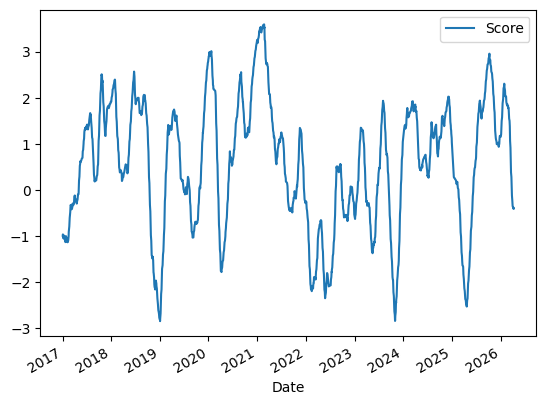

In [21]:
res_dict_ts['^RUT'][['Score']].ewm(span= 66, adjust = False).mean().plot()

# Exporting Time series:

In [22]:
dfs = []

for asset, df in res_dict_ts.items():
    tmp = df[['Close', 'Score']].copy()
    tmp.columns = pd.MultiIndex.from_product([[asset], tmp.columns])
    dfs.append(tmp)

df_panel = pd.concat(dfs, axis=1).sort_index()

#Mapping columns
df_panel = df_panel.copy()

df_panel.columns = pd.MultiIndex.from_tuples(
    [
        (index_mapper.get(asset, asset), field)
        for asset, field in df_panel.columns
    ],
    names=df_panel.columns.names
)


In [23]:
dfs = []

for asset, df in res_dict_ts.items():
    tmp = df[['Close', 'Score']].copy()
    tmp.columns = pd.MultiIndex.from_product([[asset], tmp.columns])
    dfs.append(tmp)

panel_df = pd.concat(dfs, axis=1).sort_index()


In [24]:
df_panel.tail()

BTC              SOL                ETH             XRP  \
                   Close Score      Close Score        Close Score     Close   
Date                                                                           
2026-04-05  68981.898438     2  81.854492   0.0  2108.995605   2.0  1.325496   
2026-04-06  68859.828125     2  80.151573   0.0  2107.761475   2.0  1.321221   
2026-04-07  71940.703125     2  85.648010   2.0  2241.806641   3.0  1.381490   
2026-04-08  71123.359375     2  82.581696   0.0  2190.335449   2.0  1.342373   
2026-04-09  70738.039062     2  81.710548   0.0  2168.058838   2.0  1.324458   

                          S&P        ...       Apple            Google        \
           Score        Close Score  ...       Close Score       Close Score   
Date                                 ...                                       
2026-04-05  -2.0          NaN   NaN  ...         NaN   NaN         NaN   NaN   
2026-04-06  -2.0  6611.830078  -2.0  ...  258.859985  -1.0  297.660004  -2.0   
2026-04-07   0.0  6616.850098  -2.0  ...  253.500000  -1.0  303.929993   0.0   
2026-04-08  -2.0  6782.810059  -2.0  ...  258.899994  -1.0  314.739990   1.0   
2026-04-09  -2.0  6766.839844  -2.0  ...  258.149994  -1.0  310.108612   0.0   

                 Tesla         Microsoft               Gold        
                 Close Score       Close Score        Close Score  
Date                                                               
2026-04-05         NaN   NaN         NaN   NaN          NaN   NaN  
2026-04-06  352.820007  -4.0  372.880005  -4.0  4656.799805  -3.0  
2026-04-07  346.649994  -4.0  372.290009  -4.0  4657.100098  -3.0  
2026-04-08  343.250000  -4.0  374.329987  -3.0  4749.500000  -1.0  
2026-04-09  341.089905  -4.0  367.209991  -4.0  4784.299805   0.0  

[5 rows x 36 columns]

### Pickle file export:

In [25]:
import os

desktop_path = os.path.expanduser("/Users/lollo/Desktop/Indicator tracker file/time_series_data.pkl")
df_panel.to_pickle(desktop_path)
